In [6]:
# %pip install duckdb requests pandas matplotlib

In [7]:
import duckdb, requests

manifest = requests.get("https://data.deadlock-api.com/v1/manifest.json").json()
base = manifest["public_url"]

def urls(table: str) -> list[str]:
    t = manifest["tables"][table]
    gen = t.get("generation", 0)
    return [f"{base}/{f['key']}" for f in t["files"]
            if t["policy"] == "snapshot" or f.get("generation", 0) == gen]

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
for name in manifest["tables"]:
    con.execute(f"CREATE VIEW {name} AS SELECT * FROM read_parquet({urls(name)!r}, union_by_name = true)")

print(con.sql("SELECT count(*) FROM leaderboard"))

# pandas / polars work on single files directly:
#   pd.read_parquet(urls("leaderboard")[0])
#   pl.scan_parquet(urls("match_player")).filter(pl.col("match_id") > 105_000_000)

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│     15896100 │
└──────────────┘



In [8]:
sample_urls = urls("match_player")[:20]  # Broader date window and larger sample for checkpoint analysis
sample_files = [url.rsplit("/", 1)[-1] for url in sample_urls]
sample_generation = manifest["tables"]["match_player"].get("generation", "unknown")
print(f"Using sample files: {sample_files}")
print(f"Match_player generation: {sample_generation}")

query = f"""
SELECT AVG(net_worth) AS average_souls_on_win
FROM (
    SELECT net_worth
    FROM read_parquet({sample_urls!r}, union_by_name = true)
    WHERE match_outcome = 'TeamWin'
      AND team = winning_team
    LIMIT 10000
)
"""

print(con.sql(query))

Using sample files: ['20261004T170400Z-2bcf8c938fe6.parquet', '20261004T170400Z-2bcf8c938fe6.parquet', '20261004T170400Z-2bcf8c938fe6.parquet', '20261004T170400Z-2bcf8c938fe6.parquet', '20261004T170400Z-2bcf8c938fe6.parquet', '20261004T170400Z-2bcf8c938fe6.parquet', '20261004T170400Z-2bcf8c938fe6.parquet', '20261004T170400Z-2bcf8c938fe6.parquet', '20261004T170400Z-2bcf8c938fe6.parquet', '20261004T170400Z-2bcf8c938fe6.parquet', '20261004T170400Z-2bcf8c938fe6.parquet', '20261004T170400Z-2bcf8c938fe6.parquet', '20261004T170400Z-2bcf8c938fe6.parquet', '20261004T170400Z-2bcf8c938fe6.parquet', '20261004T170400Z-2bcf8c938fe6.parquet', '20261004T170400Z-2bcf8c938fe6.parquet', '20261004T170400Z-2bcf8c938fe6.parquet', '20261004T170400Z-2bcf8c938fe6.parquet', '20261004T170400Z-2bcf8c938fe6.parquet', '20261004T170400Z-2bcf8c938fe6.parquet']
Match_player generation: 2
┌──────────────────────┐
│ average_souls_on_win │
│        double        │
├──────────────────────┤
│           26213.1339 │
└──────

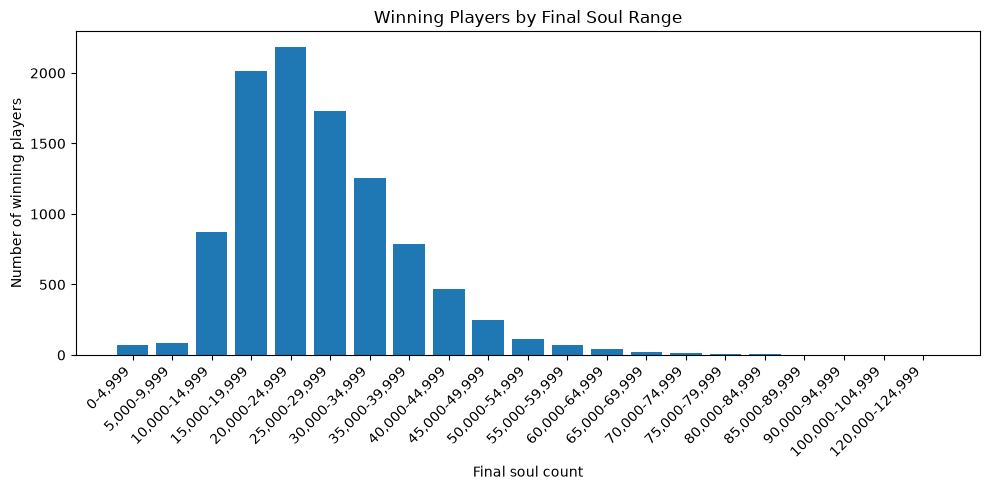

In [ ]:
import matplotlib.pyplot as plt

chart_query = f"""
SELECT
    FLOOR(net_worth / 5000) * 5000 AS range_start,
    COUNT(*) AS winning_players
FROM (
    SELECT net_worth
    FROM read_parquet({sample_urls!r}, union_by_name = true)
    WHERE match_outcome = 'TeamWin'
      AND team = winning_team
    LIMIT 10000
)
GROUP BY range_start
ORDER BY range_start
"""

chart_data = con.sql(chart_query).df()
chart_data["range"] = chart_data["range_start"].astype(int).map(
    lambda value: f"{value:,}-{value + 4999:,}"
)

plt.figure(figsize=(10, 5))
plt.bar(chart_data["range"], chart_data["winning_players"])
plt.title("Winning Players by Final Soul Range")
plt.xlabel("Final soul count")
plt.ylabel("Number of winning players")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
# To test if it works, not relevant to the study

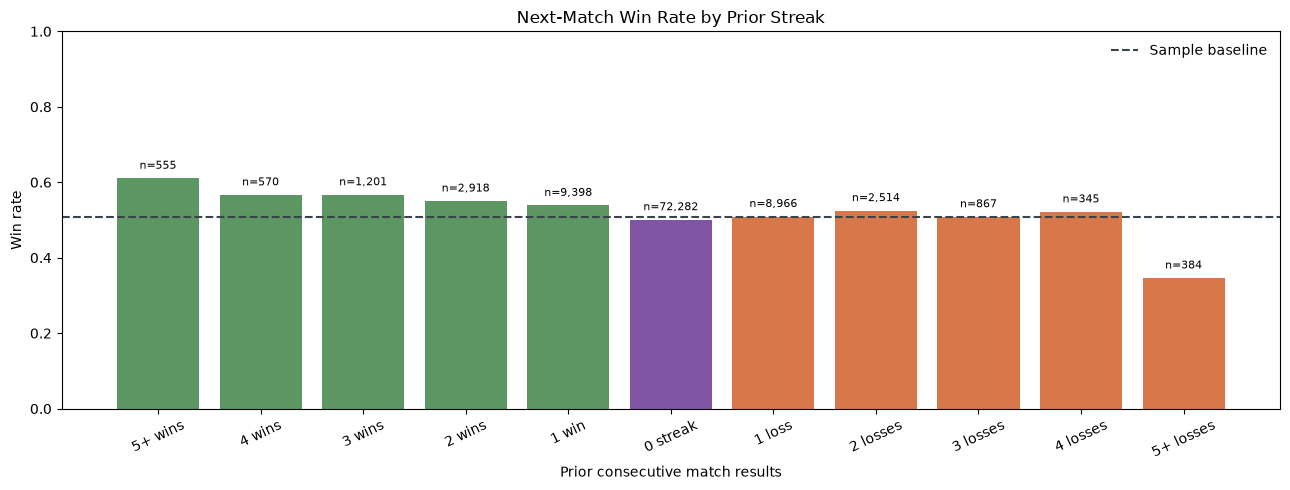

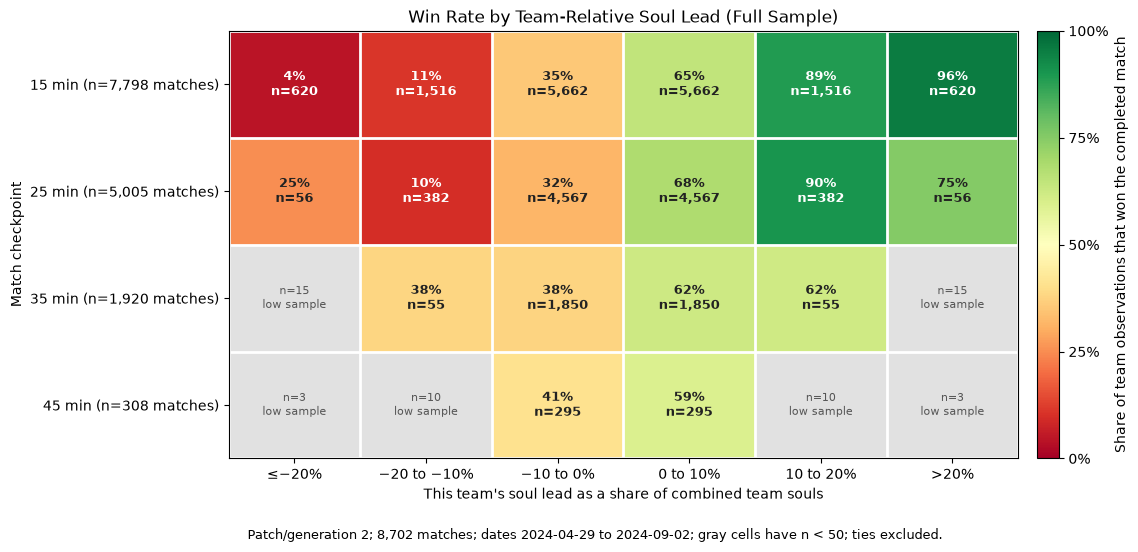

Full sample: 100,000 player-match rows; 7,798 matches with snapshots; 30,062 team observations.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Ensure the current notebook is using the 20-file sample even if earlier cells were not rerun.
if "sample_urls" not in globals():
    sample_urls = urls("match_player")[:20]
if "sample_files" not in globals():
    sample_files = [url.rsplit("/", 1)[-1] for url in sample_urls]
if "sample_generation" not in globals():
    sample_generation = manifest["tables"]["match_player"].get("generation", "unknown")

sample_start_date = "2024-04-01"
sample_end_date = "2024-12-31"
match_data = con.execute(f"""
    SELECT
        match_id,
        start_time,
        duration_s,
        account_id,
        team,
        winning_team,
        won,
        "stats.time_stamp_s" AS stat_times,
        "stats.net_worth" AS stat_souls,
        created_at
    FROM read_parquet({sample_urls!r}, union_by_name = true)
    WHERE match_outcome = 'TeamWin'
      AND won IS NOT NULL
      AND start_time >= '{sample_start_date}'
      AND start_time <= '{sample_end_date}'
    QUALIFY ROW_NUMBER() OVER (
        PARTITION BY match_id, account_id ORDER BY created_at DESC
    ) = 1
    ORDER BY start_time
    LIMIT 100000
""").df()

if match_data.empty:
    raise ValueError("No completed player-match rows were found in the sample files.")

# A positive streak means prior wins; a negative streak means prior losses.
match_data = match_data.sort_values(["account_id", "start_time"]).copy()
match_data["prior_streak"] = 0
for account_id, player_matches in match_data.groupby("account_id", sort=False):
    streak = 0
    for row_index, row in player_matches.iterrows():
        match_data.at[row_index, "prior_streak"] = streak
        if bool(row["won"]):
            streak = streak + 1 if streak > 0 else 1
        else:
            streak = streak - 1 if streak < 0 else -1

streak_labels = ["5+ wins", "4 wins", "3 wins", "2 wins", "1 win", "0 streak",
                 "1 loss", "2 losses", "3 losses", "4 losses", "5+ losses"]
def streak_group(streak):
    if streak == 0:
        return "0 streak"
    if streak > 0:
        if streak >= 5:
            return "5+ wins"
        return "1 win" if streak == 1 else f"{streak} wins"
    loss_count = abs(streak)
    return f"{loss_count} loss" if loss_count < 2 else (f"{loss_count} losses" if loss_count < 5 else "5+ losses")

match_data["streak_group"] = match_data["prior_streak"].map(streak_group)
streak_summary = match_data.groupby("streak_group").agg(
    win_rate=("won", "mean"), matches=("won", "size")
).reindex(streak_labels)
streak_colors = ["#5b9663"] * 5 + ["#8055a4"] + ["#d8784a"] * 5

fig, streak_ax = plt.subplots(figsize=(13, 5))
streak_ax.bar(streak_labels, streak_summary["win_rate"], color=streak_colors)
streak_ax.axhline(match_data["won"].mean(), color="#39434a", linestyle="--", label="Sample baseline")
streak_ax.set_title("Next-Match Win Rate by Prior Streak")
streak_ax.set_xlabel("Prior consecutive match results")
streak_ax.set_ylabel("Win rate")
streak_ax.set_ylim(0, 1)
streak_ax.tick_params(axis="x", rotation=25)
streak_ax.legend(frameon=False)
for position, (_, row) in enumerate(streak_summary.iterrows()):
    if pd.notna(row["matches"]) and row["matches"] > 0:
        streak_ax.text(position, row["win_rate"] + 0.025, f"n={int(row['matches']):,}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

checkpoints = (15, 25, 35, 45)
lead_labels = ["≤−20%", "−20 to −10%", "−10 to 0%", "0 to 10%", "10 to 20%", ">20%"]
lead_bins = [-float("inf"), -20, -10, 0, 10, 20, float("inf")]
minimum_cell_count = 50

def build_snapshot_data(match_subset):
    snapshot_rows = []
    for match_id, one_match in match_subset.groupby("match_id", sort=False):
        winning_team = one_match["winning_team"].iloc[0]
        match_duration_s = one_match["duration_s"].iloc[0]
        for minute in checkpoints:
            if pd.isna(match_duration_s) or match_duration_s < minute * 60:
                continue
            team_souls = {"Team0": 0.0, "Team1": 0.0}
            players_found = {"Team0": 0, "Team1": 0}
            for _, player in one_match.iterrows():
                player_team = player["team"]
                if player_team not in team_souls:
                    continue
                try:
                    times = list(player["stat_times"])
                    souls = list(player["stat_souls"])
                except (TypeError, ValueError):
                    continue
                valid_indices = [
                    index for index, second in enumerate(times)
                    if index < len(souls) and pd.notna(second)
                    and minute * 60 - 120 <= second <= minute * 60
                    and pd.notna(souls[index])
                ]
                if valid_indices:
                    latest_index = valid_indices[-1]
                    team_souls[player_team] += float(souls[latest_index])
                    players_found[player_team] += 1
            if not all(players_found[team] > 0 for team in ("Team0", "Team1")):
                continue

            combined_souls = team_souls["Team0"] + team_souls["Team1"]
            if combined_souls <= 0:
                continue
            for team, opposing_team in (("Team0", "Team1"), ("Team1", "Team0")):
                relative_lead_pct = 100 * (team_souls[team] - team_souls[opposing_team]) / combined_souls
                if relative_lead_pct == 0:
                    continue
                snapshot_rows.append({
                    "match_id": match_id,
                    "minute": minute,
                    "team": team,
                    "relative_gold_lead_pct": relative_lead_pct,
                    "team_won": int(winning_team == team),
                })
    return pd.DataFrame(snapshot_rows)

snapshot_data = build_snapshot_data(match_data)
if snapshot_data.empty:
    raise ValueError("No usable timestamped soul snapshots were found in the sample.")

snapshot_data["lead_group"] = pd.cut(
    snapshot_data["relative_gold_lead_pct"], bins=lead_bins, labels=lead_labels
)
summary = snapshot_data.groupby(
    ["minute", "lead_group"], observed=False
)["team_won"].agg(["mean", "count"])
win_rate_matrix = summary["mean"].unstack("lead_group").reindex(
    index=checkpoints, columns=lead_labels
)
count_matrix = summary["count"].unstack("lead_group").reindex(
    index=checkpoints, columns=lead_labels, fill_value=0
).fillna(0)
match_counts = snapshot_data.groupby("minute")["match_id"].nunique().reindex(checkpoints, fill_value=0)

plotted_values = win_rate_matrix.where(count_matrix >= minimum_cell_count).to_numpy(dtype=float)
masked_values = np.ma.masked_invalid(plotted_values)
cmap = plt.get_cmap("RdYlGn").copy()
cmap.set_bad("#e1e1e1")
heat_fig, heat_ax = plt.subplots(figsize=(12, 5.5))
image = heat_ax.imshow(
    masked_values, aspect="auto", cmap=cmap,
    norm=TwoSlopeNorm(vmin=0, vcenter=0.5, vmax=1)
)

for row_index, minute in enumerate(checkpoints):
    for column_index, lead_label in enumerate(lead_labels):
        count = int(count_matrix.loc[minute, lead_label])
        rate = win_rate_matrix.loc[minute, lead_label]
        if count >= minimum_cell_count and pd.notna(rate):
            cell_text = f"{rate:.0%}\nn={count:,}"
            text_color = "white" if rate < 0.15 or rate > 0.85 else "#222222"
            heat_ax.text(column_index, row_index, cell_text, ha="center", va="center",
                         color=text_color, fontsize=9, fontweight="bold")
        else:
            heat_ax.text(column_index, row_index, f"n={count}\nlow sample", ha="center",
                         va="center", color="#555555", fontsize=8)

heat_ax.set_xticks(np.arange(len(lead_labels)), lead_labels)
heat_ax.set_yticks(
    np.arange(len(checkpoints)),
    [f"{minute} min (n={int(match_counts.loc[minute]):,} matches)" for minute in checkpoints]
)
heat_ax.set_xlabel("This team's soul lead as a share of combined team souls")
heat_ax.set_ylabel("Match checkpoint")
heat_ax.set_title("Win Rate by Team-Relative Soul Lead (Full Sample)")
heat_ax.set_xticks(np.arange(-0.5, len(lead_labels), 1), minor=True)
heat_ax.set_yticks(np.arange(-0.5, len(checkpoints), 1), minor=True)
heat_ax.grid(which="minor", color="white", linewidth=2)
heat_ax.tick_params(which="minor", bottom=False, left=False)
colorbar = heat_fig.colorbar(image, ax=heat_ax, pad=0.02, ticks=[0, 0.25, 0.5, 0.75, 1])
colorbar.set_label("Share of team observations that won the completed match")
colorbar.ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
sample_start = pd.to_datetime(match_data["start_time"]).min().strftime("%Y-%m-%d")
sample_end = pd.to_datetime(match_data["start_time"]).max().strftime("%Y-%m-%d")
sample_label = (
    f"Patch/generation {sample_generation}; {match_data['match_id'].nunique():,} matches; "
    f"dates {sample_start} to {sample_end}; gray cells have n < {minimum_cell_count}; ties excluded."
)
heat_fig.text(0.5, 0.01, sample_label, ha="center", fontsize=9)
heat_fig.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

usable_match_count = snapshot_data["match_id"].nunique()
team_observation_count = len(snapshot_data)
print(
    f"Full sample: {len(match_data):,} player-match rows; "
    f"{usable_match_count:,} matches with snapshots; {team_observation_count:,} team observations."
)

In [11]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Predict whether a team wins using only its checkpoint minute and relative soul lead.
feature_columns = ["minute", "relative_gold_lead_pct"]
model_data = snapshot_data.dropna(subset=feature_columns + ["team_won", "match_id"]).copy()
features = model_data[feature_columns]
target = model_data["team_won"].astype(int)
match_groups = model_data["match_id"]

# Keep every observation from the same match together, including both teams and checkpoints.
train_test_splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_indices, test_indices = next(train_test_splitter.split(features, target, groups=match_groups))
x_train = features.iloc[train_indices]
x_test = features.iloc[test_indices]
y_train = target.iloc[train_indices]
y_test = target.iloc[test_indices]
groups_train = match_groups.iloc[train_indices]
assert set(groups_train).isdisjoint(set(match_groups.iloc[test_indices]))

group_cv = GroupKFold(n_splits=5)
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(x_train, y_train)
baseline_cv_auc = cross_val_score(
    DummyClassifier(strategy="most_frequent"),
    x_train,
    y_train,
    groups=groups_train,
    cv=group_cv,
    scoring="roc_auc",
).mean()

logistic_search = GridSearchCV(
    Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42)),
    ]),
    param_grid={"model__C": [0.1, 1.0, 10.0]},
    scoring="roc_auc",
    cv=group_cv,
)
logistic_search.fit(x_train, y_train, groups=groups_train)

forest_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid={
        "n_estimators": [100],
        "max_depth": [None, 10],
        "min_samples_leaf": [1, 5],
    },
    scoring="roc_auc",
    cv=group_cv,
)
forest_search.fit(x_train, y_train, groups=groups_train)

trained_models = {
    "Majority baseline": baseline,
    "Logistic regression": logistic_search.best_estimator_,
    "Random forest": forest_search.best_estimator_,
}
model_cv_auc = {
    "Majority baseline": baseline_cv_auc,
    "Logistic regression": logistic_search.best_score_,
    "Random forest": forest_search.best_score_,
}

evaluation_rows = []
for model_name, model in trained_models.items():
    predictions = model.predict(x_test)
    win_probabilities = model.predict_proba(x_test)[:, 1]
    evaluation_rows.append({
        "Model": model_name,
        "Grouped CV ROC-AUC": model_cv_auc[model_name],
        "Test accuracy": accuracy_score(y_test, predictions),
        "Test precision": precision_score(y_test, predictions, zero_division=0),
        "Test recall": recall_score(y_test, predictions, zero_division=0),
        "Test F1": f1_score(y_test, predictions, zero_division=0),
        "Test ROC-AUC": roc_auc_score(y_test, win_probabilities),
    })

evaluation_results = pd.DataFrame(evaluation_rows).set_index("Model")
print(f"Training team observations: {len(x_train):,}; test team observations: {len(x_test):,}")
print(f"Training matches: {groups_train.nunique():,}; test matches: {match_groups.iloc[test_indices].nunique():,}")
print("All rows from each match are kept together in the split.")
print("\nEvaluation results:")
print(evaluation_results.round(3))
print("\nBest logistic regression settings:", logistic_search.best_params_)
print("Best random forest settings:", forest_search.best_params_)
selected_model_name = max(
    ("Logistic regression", "Random forest"),
    key=lambda model_name: model_cv_auc[model_name],
)
print(f"Selected by grouped cross-validation ROC-AUC: {selected_model_name}")

Training team observations: 23,956; test team observations: 6,106
Training matches: 6,238; test matches: 1,560
All rows from each match are kept together in the split.

Evaluation results:
                     Grouped CV ROC-AUC  Test accuracy  Test precision  \
Model                                                                    
Majority baseline                 0.500          0.500           0.000   
Logistic regression               0.775          0.694           0.694   
Random forest                     0.769          0.681           0.681   

                     Test recall  Test F1  Test ROC-AUC  
Model                                                    
Majority baseline          0.000    0.000         0.500  
Logistic regression        0.694    0.694         0.762  
Random forest              0.683    0.682         0.757  

Best logistic regression settings: {'model__C': 0.1}
Best random forest settings: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100}
Selec

In [12]:
from sklearn.metrics import confusion_matrix

final_model = trained_models[selected_model_name]
final_predictions = final_model.predict(x_test)
final_win_probabilities = final_model.predict_proba(x_test)[:, 1]

confusion = confusion_matrix(y_test, final_predictions, labels=[0, 1])
confusion_table = pd.DataFrame(
    confusion,
    index=["Actual loss", "Actual win"],
    columns=["Predicted loss", "Predicted win"],
)
print("Logistic regression confusion matrix:")
print(confusion_table)

logistic_coefficients = logistic_search.best_estimator_.named_steps["model"].coef_[0]
coefficient_table = pd.DataFrame({
    "Feature": feature_columns,
    "Standardized coefficient": logistic_coefficients,
    "Odds ratio per standard deviation": np.exp(logistic_coefficients),
}).sort_values("Standardized coefficient", key=lambda values: values.abs(), ascending=False)
print("\nLogistic regression coefficients (features are standardized):")
print(coefficient_table.round(3).to_string(index=False))

importance_table = pd.DataFrame({
    "Feature": feature_columns,
    "Random forest importance": forest_search.best_estimator_.feature_importances_,
}).sort_values("Random forest importance", ascending=False)
print("\nRandom forest feature importance:")
print(importance_table.round(3).to_string(index=False))

test_diagnostics = model_data.iloc[test_indices][
    ["match_id", "team", "minute", "relative_gold_lead_pct"]
].reset_index(drop=True)
test_diagnostics["actual_win"] = y_test.to_numpy()
test_diagnostics["predicted_win"] = final_predictions
test_diagnostics["win_probability"] = final_win_probabilities
test_diagnostics["probability_residual"] = (
    test_diagnostics["actual_win"] - test_diagnostics["win_probability"]
)

checkpoint_rows = []
for minute, checkpoint_data in test_diagnostics.groupby("minute"):
    checkpoint_rows.append({
        "Minute": minute,
        "Team observations": len(checkpoint_data),
        "Accuracy": accuracy_score(checkpoint_data["actual_win"], checkpoint_data["predicted_win"]),
        "ROC-AUC": roc_auc_score(checkpoint_data["actual_win"], checkpoint_data["win_probability"]),
        "Mean absolute probability residual": checkpoint_data["probability_residual"].abs().mean(),
    })
checkpoint_results = pd.DataFrame(checkpoint_rows).set_index("Minute")
print("\nFinal model performance by checkpoint:")
print(checkpoint_results.round(3))

example_predictions = test_diagnostics.sample(
    n=min(10, len(test_diagnostics)), random_state=42
)[["match_id", "team", "minute", "relative_gold_lead_pct", "actual_win", "predicted_win", "win_probability"]]
example_predictions["relative_gold_lead_pct"] = example_predictions["relative_gold_lead_pct"].round(1)
example_predictions["win_probability"] = example_predictions["win_probability"].round(3)
print("\nExample held-out predictions (actual_win and predicted_win: 1=win, 0=loss):")
print(example_predictions.to_string(index=False))

Logistic regression confusion matrix:
             Predicted loss  Predicted win
Actual loss            2119            934
Actual win              934           2119

Logistic regression coefficients (features are standardized):
               Feature  Standardized coefficient  Odds ratio per standard deviation
relative_gold_lead_pct                     1.852                              6.375
                minute                     0.000                              1.000

Random forest feature importance:
               Feature  Random forest importance
relative_gold_lead_pct                     0.987
                minute                     0.013

Final model performance by checkpoint:
        Team observations  Accuracy  ROC-AUC  \
Minute                                         
15                   3120     0.708    0.793   
25                   2040     0.708    0.764   
35                    812     0.621    0.649   
45                    134     0.597    0.646   

       